In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install librosa
!pip install soundfile
!pip install noisereduce
!pip install webrtcvad
!pip install audiomentations
!pip install tensorflow
!pip install torch
!pip install torchaudio
!pip install transformers
!pip install scikit-learn
!pip install pandas
!pip install numpy
!pip install shap
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for webrtcvad: filename=webrtcvad-2.0.10-cp312-cp312-linux_x86_64.whl size=73520 sha256=973d2dfc9942bea8b51cb43398c4206955f47756397895a85f047fe4b5ad1c66
  Stored in directory: /root/.cache/pip/wheels/1e/d3/95/680fa3b16848f1a58d2edaed34c496224c89a9bc63e17b3614
Successfully built webrtcvad
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 16.7 MB/s eta 0:00:00
  Attempting uninstall: soxr
    Found existing installation: soxr 1.1.0
    Uninstalling soxr-1.1.0:
      Successfully uninstalled soxr-1.1.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import tensorflow as tf

print(tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

path = "/content/drive/MyDrive/SER/data/raw"

print(os.listdir(path))

['RAVDESS.zip', 'TESS.zip', 'CREMA_D.zip']


In [ ]:
import zipfile

zip_path = "/content/drive/MyDrive/SER/data/raw/RAVDESS.zip"
extract_path = "/content/drive/MyDrive/SER/data/raw/RAVDESS"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("RAVDESS Extracted")

RAVDESS Extracted


In [ ]:
zip_path = "/content/drive/MyDrive/SER/data/raw/TESS.zip"
extract_path = "/content/drive/MyDrive/SER/data/raw/TESS"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("TESS Extracted")

TESS Extracted


In [ ]:
zip_path = "/content/drive/MyDrive/SER/data/raw/CREMA_D.zip"
extract_path = "/content/drive/MyDrive/SER/data/raw/CREMA_D"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("CREMA_D Extracted")

CREMA_D Extracted


In [ ]:
import os

path = "/content/drive/MyDrive/SER/data/raw"
print(os.listdir(path))

['RAVDESS.zip', 'TESS.zip', 'CREMA_D.zip', 'RAVDESS', 'TESS', 'CREMA_D']


In [ ]:
import os

print("RAVDESS contents:")
for item in os.listdir("/content/drive/MyDrive/SER/data/raw/RAVDESS"):
    print(item)

RAVDESS contents:
Actor_01
Actor_02
Actor_03
Actor_04
Actor_05
Actor_06
Actor_07
Actor_08
Actor_09
Actor_10
Actor_11
Actor_12
Actor_13
Actor_14
Actor_15
Actor_16
Actor_17
Actor_18
Actor_19
Actor_20
Actor_21
Actor_22
Actor_23
Actor_24
audio_speech_actors_01-24


In [ ]:
import os

print("TESS contents:")
for item in os.listdir("/content/drive/MyDrive/SER/data/raw/TESS"):
    print(item)

TESS contents:
TESS Toronto emotional speech set data
tess toronto emotional speech set data


## **Create Master Manifest**

In [ ]:
import pandas as pd

manifest = []

emotion_map_ravdess = {
    "01":"neutral",
    "02":"calm",
    "03":"happy",
    "04":"sad",
    "05":"angry",
    "06":"fearful",
    "07":"disgust",
    "08":"surprised"
}

manifest_df = pd.DataFrame(
    manifest,
    columns=[
        "file_path",
        "emotion",
        "dataset"
    ]
)

print(manifest_df.head())

Empty DataFrame
Columns: [file_path, emotion, dataset]
Index: []


In [ ]:
import os
import pandas as pd

manifest = []

emotion_map_ravdess = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

ravdess_path = "/content/drive/MyDrive/SER/data/raw/RAVDESS"

for actor_folder in os.listdir(ravdess_path):

    # Ignore duplicate folder
    if actor_folder == "audio_speech_actors_01-24":
        continue

    actor_path = os.path.join(ravdess_path, actor_folder)

    if not os.path.isdir(actor_path):
        continue

    for file in os.listdir(actor_path):

        if file.endswith(".wav"):

            emotion_code = file.split("-")[2]

            emotion = emotion_map_ravdess.get(emotion_code)

            manifest.append({
                "file_path": os.path.join(actor_path, file),
                "emotion": emotion,
                "dataset": "RAVDESS"
            })

ravdess_df = pd.DataFrame(manifest)

print("RAVDESS Samples:", len(ravdess_df))
ravdess_df.head()

RAVDESS Samples: 1440


,file_path,emotion,dataset
0,/content/drive/MyDrive/SER/data/raw/RAVDESS/Ac...,neutral,RAVDESS
1,/content/drive/MyDrive/SER/data/raw/RAVDESS/Ac...,neutral,RAVDESS
2,/content/drive/MyDrive/SER/data/raw/RAVDESS/Ac...,neutral,RAVDESS
3,/content/drive/MyDrive/SER/data/raw/RAVDESS/Ac...,neutral,RAVDESS
4,/content/drive/MyDrive/SER/data/raw/RAVDESS/Ac...,calm,RAVDESS


In [ ]:
print(ravdess_df["emotion"].value_counts())

emotion
calm         192
happy        192
sad          192
angry        192
disgust      192
fearful      192
surprised    192
neutral       96
Name: count, dtype: int64


In [ ]:
tess_path = "/content/drive/MyDrive/SER/data/raw/TESS/TESS Toronto emotional speech set data"

tess_manifest = []

for emotion_folder in os.listdir(tess_path):

    folder_path = os.path.join(tess_path, emotion_folder)

    if not os.path.isdir(folder_path):
        continue

    emotion = emotion_folder.lower()

    if emotion == "ps":
        emotion = "surprised"

    for file in os.listdir(folder_path):

        if file.endswith(".wav"):

            tess_manifest.append({
                "file_path": os.path.join(folder_path, file),
                "emotion": emotion,
                "dataset": "TESS"
            })

tess_df = pd.DataFrame(tess_manifest)

print("TESS Samples:", len(tess_df))
print()
print(tess_df["emotion"].value_counts())

TESS Samples: 2800

emotion
oaf_fear                  200
oaf_pleasant_surprise     200
oaf_sad                   200
oaf_angry                 200
oaf_disgust               200
oaf_happy                 200
oaf_neutral               200
yaf_angry                 200
yaf_disgust               200
yaf_fear                  200
yaf_happy                 200
yaf_neutral               200
yaf_pleasant_surprised    200
yaf_sad                   200
Name: count, dtype: int64


In [ ]:
tess_df["emotion"].value_counts()

,count
emotion,
oaf_fear,200
oaf_pleasant_surprise,200
oaf_sad,200
oaf_angry,200
oaf_disgust,200
oaf_happy,200
oaf_neutral,200
yaf_angry,200
yaf_disgust,200


In [ ]:
import os
import pandas as pd

tess_path = "/content/drive/MyDrive/SER/data/raw/TESS/TESS Toronto emotional speech set data"

tess_manifest = []

emotion_mapping = {
    "angry": "angry",
    "disgust": "disgust",
    "fear": "fearful",
    "happy": "happy",
    "neutral": "neutral",
    "sad": "sad",
    "pleasant_surprise": "surprised",
    "pleasant_surprised": "surprised"
}

for emotion_folder in os.listdir(tess_path):

    folder_path = os.path.join(tess_path, emotion_folder)

    if not os.path.isdir(folder_path):
        continue

    emotion_name = emotion_folder.lower()

    # Remove speaker prefix
    emotion_name = emotion_name.replace("oaf_", "")
    emotion_name = emotion_name.replace("yaf_", "")

    emotion_name = emotion_mapping.get(emotion_name)

    for file in os.listdir(folder_path):

        if file.endswith(".wav"):

            tess_manifest.append({
                "file_path": os.path.join(folder_path, file),
                "emotion": emotion_name,
                "dataset": "TESS"
            })

tess_df = pd.DataFrame(tess_manifest)

print("TESS Samples:", len(tess_df))
print()
print(tess_df["emotion"].value_counts())

TESS Samples: 2800

emotion
fearful      400
surprised    400
sad          400
angry        400
disgust      400
happy        400
neutral      400
Name: count, dtype: int64


In [ ]:
import os
import pandas as pd

crema_path = "/content/drive/MyDrive/SER/data/raw/CREMA_D/AudioWAV"

crema_manifest = []

emotion_map = {
    "ANG": "angry",
    "DIS": "disgust",
    "FEA": "fearful",
    "HAP": "happy",
    "NEU": "neutral",
    "SAD": "sad"
}

for file in os.listdir(crema_path):

    if not file.endswith(".wav"):
        continue

    parts = file.split("_")

    emotion_code = parts[2]

    emotion = emotion_map.get(emotion_code)

    if emotion is None:
        continue

    crema_manifest.append({
        "file_path": os.path.join(crema_path, file),
        "emotion": emotion,
        "dataset": "CREMA-D"
    })

crema_df = pd.DataFrame(crema_manifest)

print("CREMA-D Samples:", len(crema_df))
print()
print(crema_df["emotion"].value_counts())

CREMA-D Samples: 7442

emotion
angry      1271
disgust    1271
fearful    1271
happy      1271
sad        1271
neutral    1087
Name: count, dtype: int64


In [ ]:
crema_df["emotion"].value_counts()


,count
emotion,
angry,1271
disgust,1271
fearful,1271
happy,1271
sad,1271
neutral,1087


# **Merge All Datasets**

In [ ]:
final_manifest = pd.concat(
    [ravdess_df, tess_df, crema_df],
    ignore_index=True
)

print("Total Samples:", len(final_manifest))

print("\nEmotion Distribution:")
print(final_manifest["emotion"].value_counts())

Total Samples: 11682

Emotion Distribution:
emotion
sad          1863
happy        1863
fearful      1863
angry        1863
disgust      1863
neutral      1583
surprised     592
calm          192
Name: count, dtype: int64


In [ ]:
manifest_path = "/content/drive/MyDrive/SER/manifest.csv"

final_manifest.to_csv(
    manifest_path,
    index=False
)

print("Manifest saved successfully!")
print(manifest_path)

Manifest saved successfully!
/content/drive/MyDrive/SER/manifest.csv


# **Verify Manifest**

In [ ]:
manifest = pd.read_csv(
    "/content/drive/MyDrive/SER/manifest.csv"
)

print(manifest.shape)

manifest.head()

(11682, 3)


,file_path,emotion,dataset
0,/content/drive/MyDrive/SER/data/raw/RAVDESS/Ac...,neutral,RAVDESS
1,/content/drive/MyDrive/SER/data/raw/RAVDESS/Ac...,neutral,RAVDESS
2,/content/drive/MyDrive/SER/data/raw/RAVDESS/Ac...,neutral,RAVDESS
3,/content/drive/MyDrive/SER/data/raw/RAVDESS/Ac...,neutral,RAVDESS
4,/content/drive/MyDrive/SER/data/raw/RAVDESS/Ac...,calm,RAVDESS


# **Phase 3 - Audio Preprocessing**

In [ ]:
import pandas as pd

manifest = pd.read_csv(
    "/content/drive/MyDrive/SER/manifest.csv"
)

print(manifest.shape)

manifest.head()

(11682, 3)


,file_path,emotion,dataset
0,/content/drive/MyDrive/SER/data/raw/RAVDESS/Ac...,neutral,RAVDESS
1,/content/drive/MyDrive/SER/data/raw/RAVDESS/Ac...,neutral,RAVDESS
2,/content/drive/MyDrive/SER/data/raw/RAVDESS/Ac...,neutral,RAVDESS
3,/content/drive/MyDrive/SER/data/raw/RAVDESS/Ac...,neutral,RAVDESS
4,/content/drive/MyDrive/SER/data/raw/RAVDESS/Ac...,calm,RAVDESS


# **Select One Sample Audio**

In [ ]:
sample_path = manifest.iloc[0]["file_path"]

print(sample_path)

/content/drive/MyDrive/SER/data/raw/RAVDESS/Actor_01/03-01-01-01-01-01-01.wav


# **Load Audio**

In [ ]:
import librosa

audio, sr = librosa.load(
    sample_path,
    sr=16000
)

print("Sample Rate:", sr)
print("Audio Shape:", audio.shape)

Sample Rate: 16000
Audio Shape: (52853,)


# **Visualize Original Waveform**

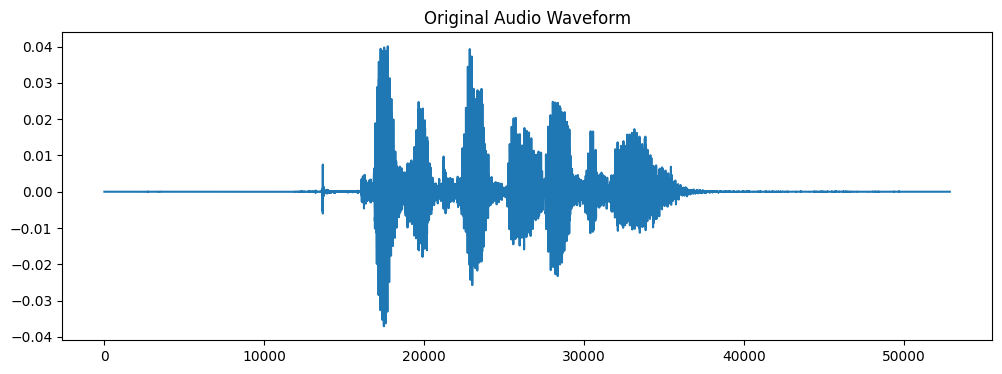

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(audio)
plt.title("Original Audio Waveform")
plt.show()

# **Check Duration**

In [ ]:
duration = librosa.get_duration(
    y=audio,
    sr=sr
)

print("Duration:", round(duration,2), "seconds")

Duration: 3.3 seconds


# **Normalize Audio**

In [ ]:
audio_norm = librosa.util.normalize(audio)

print("Normalization Complete")

Normalization Complete


# **Noise Reduction**

In [ ]:
!pip install noisereduce

In [ ]:
import noisereduce as nr

audio_denoised = nr.reduce_noise(
    y=audio_norm,
    sr=sr
)

print("Noise Reduction Complete")

Noise Reduction Complete


# **Remove Silence**

In [ ]:
audio_trimmed, _ = librosa.effects.trim(
    audio_denoised
)

print("Silence Removed")

Silence Removed


# **Compare Durations**

In [ ]:
original_duration = librosa.get_duration(
    y=audio,
    sr=sr
)

processed_duration = librosa.get_duration(
    y=audio_trimmed,
    sr=sr
)

print("Original:", round(original_duration,2))
print("Processed:", round(processed_duration,2))

Original: 3.3
Processed: 1.54


# **Save Processed Audio**

In [ ]:
import os

os.makedirs(
    "/content/drive/MyDrive/SER/data/processed",
    exist_ok=True
)

In [ ]:
import soundfile as sf

output_path = "/content/drive/MyDrive/SER/data/processed/sample_processed.wav"

sf.write(
    output_path,
    audio_trimmed,
    sr
)

print("Saved:", output_path)

Saved: /content/drive/MyDrive/SER/data/processed/sample_processed.wav


# **Verify File Exists**

In [ ]:
import os

print(
    os.path.exists(
        "/content/drive/MyDrive/SER/data/processed/sample_processed.wav"
    )
)

True


**Next Step: Batch Preprocess All 11,682 Files**

In [ ]:
import os

processed_dir = "/content/drive/MyDrive/SER/data/processed"

os.makedirs(processed_dir, exist_ok=True)

print("Processed folder ready")

Processed folder ready


# **Batch Processing Script**

In [ ]:
import os
import librosa
import soundfile as sf
import pandas as pd
from tqdm import tqdm

manifest = pd.read_csv(
    "/content/drive/MyDrive/SER/manifest.csv"
)

processed_records = []

for idx, row in tqdm(manifest.iterrows(), total=len(manifest)):

    try:

        file_path = row["file_path"]
        emotion = row["emotion"]
        dataset = row["dataset"]

        audio, sr = librosa.load(
            file_path,
            sr=16000
        )

        # Normalize
        audio = librosa.util.normalize(audio)

        # Trim silence
        audio, _ = librosa.effects.trim(audio)

        filename = os.path.basename(file_path)

        output_path = os.path.join(
            processed_dir,
            filename
        )

        sf.write(
            output_path,
            audio,
            sr
        )

        processed_records.append({
            "file_path": output_path,
            "emotion": emotion,
            "dataset": dataset
        })

    except Exception as e:
        print("Error:", file_path)
        print(e)

100%|██████████| 11682/11682 [04:33<00:00, 42.78it/s]


# **Save Processed Manifest**

In [ ]:
processed_manifest = pd.DataFrame(
    processed_records
)

processed_manifest.to_csv(
    "/content/drive/MyDrive/SER/processed_manifest.csv",
    index=False
)

print(processed_manifest.shape)

(11682, 3)


# **Phase 4 —Feature Extraction**

### **Step 1: Test on One Audio File**

In [ ]:
audio, sr = librosa.load(
    sample_path,
    sr=16000
)

print("Sample Rate:", sr)
print("Audio Shape:", audio.shape)

Sample Rate: 16000
Audio Shape: (24576,)


**Step 2: Extract MFCC**

In [ ]:
mfcc = librosa.feature.mfcc(
    y=audio,
    sr=sr,
    n_mfcc=40
)

print(mfcc.shape)

(40, 49)


**Step 3: Delta MFCC**

In [ ]:
mfcc = librosa.feature.mfcc(
    y=audio,
    sr=sr,
    n_mfcc=40
)

print(mfcc.shape)

(40, 49)


**Step 4: Delta-Delta MFCC**

In [ ]:
delta2_mfcc = librosa.feature.delta(
    mfcc,
    order=2
)

print(delta2_mfcc.shape)

(40, 49)


**Step 5: Chroma**

In [ ]:
chroma = librosa.feature.chroma_stft(
    y=audio,
    sr=sr
)

print(chroma.shape)

(12, 49)


**Step 6: Spectral Contrast**

In [ ]:
spectral_contrast = librosa.feature.spectral_contrast(
    y=audio,
    sr=sr
)

print(spectral_contrast.shape)

(7, 49)


# **Spectral Roll-off**

In [ ]:
rolloff = librosa.feature.spectral_rolloff(
    y=audio,
    sr=sr
)

print(rolloff.shape)

(1, 49)


# **Step 8: RMS Energy**

In [ ]:
rms = librosa.feature.rms(
    y=audio
)

print(rms.shape)

(1, 49)



# **Step 9: Zero Crossing Rate**

In [ ]:
zcr = librosa.feature.zero_crossing_rate(
    audio
)

print(zcr.shape)

(1, 49)


# **Step 10: Pitch Extraction**

In [ ]:
f0 = librosa.yin(
    audio,
    fmin=50,
    fmax=500
)

print(f0.shape)

(49,)


# **Step 11: Tempo**

In [ ]:
tempo, beats = librosa.beat.beat_track(
    y=audio,
    sr=sr
)

print("Tempo:", tempo)

Tempo: [81.52173913]


In [ ]:
delta_mfcc = librosa.feature.delta(mfcc)

print(delta_mfcc.shape)

(40, 49)


**Step 12: Convert to Fixed-Length Feature Vector**

In [ ]:
features = {
    "mfcc_mean": np.mean(mfcc),
    "mfcc_std": np.std(mfcc),

    "delta_mean": np.mean(delta_mfcc),
    "delta_std": np.std(delta_mfcc),

    "chroma_mean": np.mean(chroma),
    "chroma_std": np.std(chroma),

    "rms_mean": np.mean(rms),
    "rms_std": np.std(rms),

    "zcr_mean": np.mean(zcr),
    "zcr_std": np.std(zcr),

    "pitch_mean": np.mean(f0),
    "pitch_std": np.std(f0),

    "tempo": float(tempo)
}

print(features)

{'mfcc_mean': np.float32(-10.799734), 'mfcc_std': np.float32(59.470974), 'delta_mean': np.float32(0.050501525), 'delta_std': np.float32(6.6731253), 'chroma_mean': np.float32(0.34816888), 'chroma_std': np.float32(0.3138538), 'rms_mean': np.float32(0.06932063), 'rms_std': np.float32(0.05013714), 'zcr_mean': np.float64(0.19336933992346939), 'zcr_std': np.float64(0.20026076623821817), 'pitch_mean': np.float64(169.3059425139505), 'pitch_std': np.float64(64.46435335846907), 'tempo': 81.52173913043478}


/tmp/ipykernel_2752/904954979.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  "tempo": float(tempo)


# **Create a Reusable Feature Function**

In [ ]:
import librosa
import numpy as np

def extract_features(audio_path):

    audio, sr = librosa.load(audio_path, sr=16000)

    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
    delta_mfcc = librosa.feature.delta(mfcc)

    chroma = librosa.feature.chroma_stft(y=audio, sr=sr)
    rms = librosa.feature.rms(y=audio)
    zcr = librosa.feature.zero_crossing_rate(audio)

    f0 = librosa.yin(audio, fmin=50, fmax=500)

    tempo, _ = librosa.beat.beat_track(y=audio, sr=sr)

    return {
        "mfcc_mean": np.mean(mfcc),
        "mfcc_std": np.std(mfcc),

        "delta_mean": np.mean(delta_mfcc),
        "delta_std": np.std(delta_mfcc),

        "chroma_mean": np.mean(chroma),
        "chroma_std": np.std(chroma),

        "rms_mean": np.mean(rms),
        "rms_std": np.std(rms),

        "zcr_mean": np.mean(zcr),
        "zcr_std": np.std(zcr),

        "pitch_mean": np.mean(f0),
        "pitch_std": np.std(f0),

        "tempo": float(np.asarray(tempo).item())
    }

In [ ]:
sample_features = extract_features(sample_path)

print(sample_features)

{'mfcc_mean': np.float32(-10.799734), 'mfcc_std': np.float32(59.470974), 'delta_mean': np.float32(0.050501525), 'delta_std': np.float32(6.6731253), 'chroma_mean': np.float32(0.34816888), 'chroma_std': np.float32(0.3138538), 'rms_mean': np.float32(0.06932063), 'rms_std': np.float32(0.05013714), 'zcr_mean': np.float64(0.19336933992346939), 'zcr_std': np.float64(0.20026076623821817), 'pitch_mean': np.float64(169.3059425139505), 'pitch_std': np.float64(64.46435335846907), 'tempo': 81.52173913043478}


# **Next Step: Generate Features for First 1000 Files**

In [ ]:
import pandas as pd

manifest = pd.read_csv(
    "/content/drive/MyDrive/SER/manifest.csv"
)

manifest = manifest.head(1000)

print(manifest.shape)

(1000, 3)


In [ ]:
import pandas as pd

manifest = pd.read_csv(
    "/content/drive/MyDrive/SER/manifest.csv"
)

manifest = manifest.head(1000)

print(manifest.shape)

(1000, 3)


In [ ]:
from tqdm import tqdm
import pandas as pd

feature_rows = []

for _, row in tqdm(manifest.iterrows(), total=len(manifest)):

    try:

        features = extract_features(
            row["file_path"]
        )

        features["emotion"] = row["emotion"]
        features["dataset"] = row["dataset"]

        feature_rows.append(features)

    except Exception as e:

        print("Error:", row["file_path"])
        print(e)

100%|██████████| 1000/1000 [01:06<00:00, 15.08it/s]


# **Create DataFrame**

In [ ]:
features_df = pd.DataFrame(feature_rows)

print(features_df.shape)

features_df.head()

(1000, 15)


,mfcc_mean,mfcc_std,delta_mean,delta_std,chroma_mean,chroma_std,rms_mean,rms_std,zcr_mean,zcr_std,pitch_mean,pitch_std,tempo,emotion,dataset
0,-17.954010,114.134499,-0.003946,3.490430,0.589169,0.299885,0.002327,0.003232,0.388470,0.259118,115.178955,59.117260,78.1250,neutral,RAVDESS
1,-17.609541,112.377380,0.004518,3.154515,0.562428,0.303420,0.002504,0.003449,0.393392,0.267818,128.260322,78.208207,156.2500,neutral,RAVDESS
2,-17.582190,111.632393,-0.012840,3.915791,0.572414,0.296967,0.002846,0.004172,0.411479,0.278183,114.343681,56.904555,125.0000,neutral,RAVDESS
3,-17.353930,110.789703,-0.006264,3.875191,0.567428,0.284023,0.002660,0.004047,0.400679,0.262333,113.245781,56.025933,125.0000,neutral,RAVDESS
4,-18.045849,116.026566,-0.028661,3.441073,0.536412,0.303395,0.001704,0.002402,0.376575,0.266759,114.738008,50.113128,117.1875,calm,RAVDESS


In [ ]:
features_df.to_csv(
    "/content/drive/MyDrive/SER/tabular_features_1000.csv",
    index=False
)

print("Saved Successfully")

Saved Successfully


In [ ]:
print(
    features_df["emotion"].value_counts()
)

emotion
calm         136
happy        136
sad          136
angry        136
fearful      132
disgust      128
surprised    128
neutral       68
Name: count, dtype: int64


In [ ]:
print(features_df.shape)
print(features_df["emotion"].value_counts())

(1000, 15)
emotion
calm         136
happy        136
sad          136
angry        136
fearful      132
disgust      128
surprised    128
neutral       68
Name: count, dtype: int64


# **Phase 5: Train Your First Random Forest Model**

**Step 1: Prepare Data**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

X = features_df.drop(
    columns=["emotion", "dataset"]
)

y = features_df["emotion"]

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print(label_encoder.classes_)

['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']


**Step 2: Train-Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(X_train.shape)
print(X_test.shape)

(800, 13)
(200, 13)


**Step 3: Train Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

print("Training Complete")

Training Complete


**Step 4: Predictions**

In [ ]:
y_pred = rf.predict(X_test)

**Step 5: Accuracy**

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.445


**Step 6: Detailed Metrics**

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

       angry       0.56      0.52      0.54        27
        calm       0.49      0.63      0.55        27
     disgust       0.35      0.42      0.39        26
     fearful       0.60      0.58      0.59        26
       happy       0.32      0.30      0.31        27
     neutral       0.25      0.14      0.18        14
         sad       0.41      0.33      0.37        27
   surprised       0.45      0.50      0.47        26

    accuracy                           0.45       200
   macro avg       0.43      0.43      0.42       200
weighted avg       0.44      0.45      0.44       200



**Step 7: Confusion Matrix**

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[14  0  1  1  4  0  1  6]
 [ 1 17  1  0  0  4  4  0]
 [ 5  3 11  1  2  0  2  2]
 [ 1  1  3 15  3  1  1  1]
 [ 2  1  6  2  8  1  3  4]
 [ 0  6  3  0  1  2  1  1]
 [ 0  6  5  2  3  0  9  2]
 [ 2  1  1  4  4  0  1 13]]


**Step 8: Visualize Confusion Matrix**

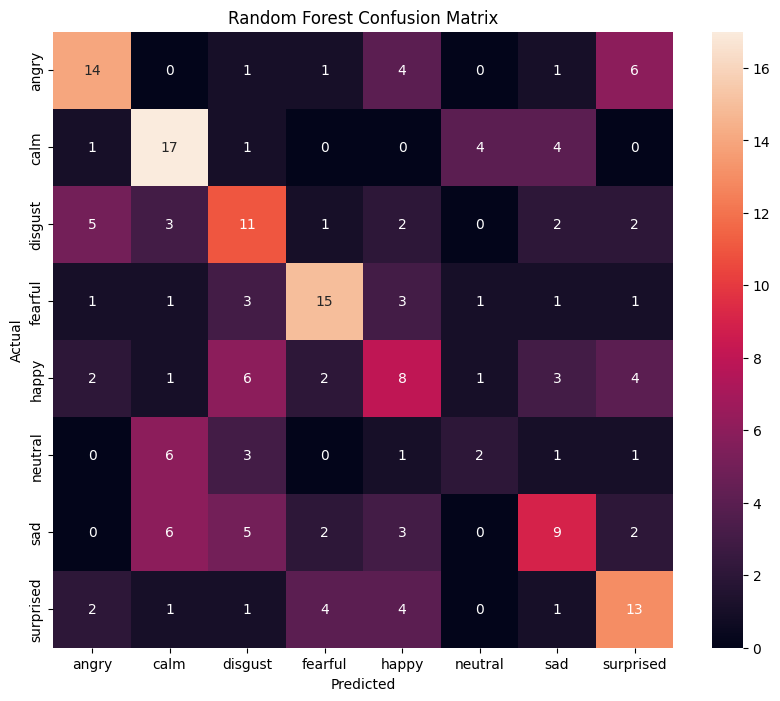

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [ ]:
print("Accuracy:", accuracy)

Accuracy: 0.445


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

       angry       0.56      0.52      0.54        27
        calm       0.49      0.63      0.55        27
     disgust       0.35      0.42      0.39        26
     fearful       0.60      0.58      0.59        26
       happy       0.32      0.30      0.31        27
     neutral       0.25      0.14      0.18        14
         sad       0.41      0.33      0.37        27
   surprised       0.45      0.50      0.47        26

    accuracy                           0.45       200
   macro avg       0.43      0.43      0.42       200
weighted avg       0.44      0.45      0.44       200



In [ ]:
mel_spec = librosa.feature.melspectrogram(
    y=audio,
    sr=16000,
    n_mels=128
)

mel_spec_db = librosa.power_to_db(
    mel_spec,
    ref=np.max
)

# **Next Recommended Stage**

Move to:

Mel Spectrogram Generation
↓
CNN
↓
CNN + BiLSTM
↓
Wav2Vec2

# **Phase 6 — Mel Spectrogram Generation for CNN**

In [ ]:
import pandas as pd

manifest = pd.read_csv(
    "/content/drive/MyDrive/SER/manifest.csv"
)

manifest = manifest.head(1000)

print(manifest.shape)

(1000, 3)


**Step 2: Create Spectrogram Function**

In [ ]:
import librosa
import numpy as np

def extract_mel_spectrogram(audio_path):

    audio, sr = librosa.load(
        audio_path,
        sr=16000
    )

    mel_spec = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_mels=128
    )

    mel_spec_db = librosa.power_to_db(
        mel_spec,
        ref=np.max
    )

    return mel_spec_db

**Step 3: Test on One File**

In [ ]:
sample_path = manifest.iloc[0]["file_path"]

mel = extract_mel_spectrogram(
    sample_path
)

print(mel.shape)

(128, 104)


**Step 4: Visualize Spectrogram**

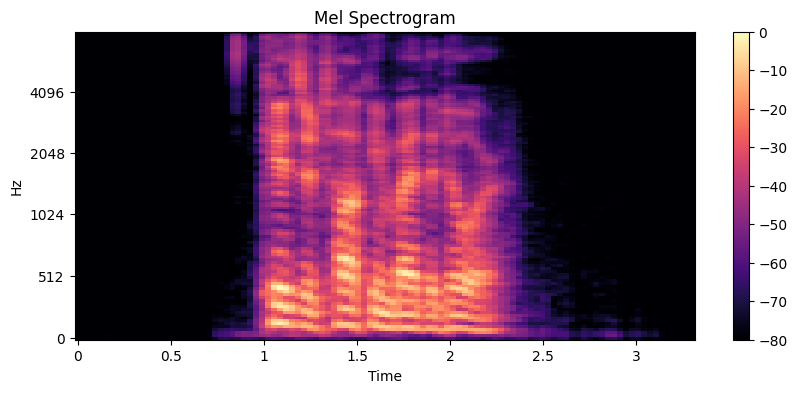

In [ ]:
import matplotlib.pyplot as plt
import librosa.display

plt.figure(figsize=(10,4))

librosa.display.specshow(
    mel,
    sr=16000,
    x_axis='time',
    y_axis='mel'
)

plt.colorbar()
plt.title("Mel Spectrogram")
plt.show()

**Step 5: Make All Spectrograms Same Size**

In [ ]:
def pad_or_truncate(spec,
                    target_length=128):

    if spec.shape[1] < target_length:

        pad_width = (
            target_length -
            spec.shape[1]
        )

        spec = np.pad(
            spec,
            ((0,0),
             (0,pad_width)),
            mode='constant'
        )

    else:

        spec = spec[:, :target_length]

    return spec

**Step 6: Test Padding**

In [ ]:
mel_fixed = pad_or_truncate(
    mel,
    target_length=128
)

print(mel_fixed.shape)

(128, 128)


**Step 7: Create Label Encode**

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

labels = label_encoder.fit_transform(
    manifest["emotion"]
)

print(label_encoder.classes_)

['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']


**Step 8: Generate Dataset**

In [ ]:
from tqdm import tqdm

X = []
y = []

for idx, row in tqdm(
    manifest.iterrows(),
    total=len(manifest)
):

    try:

        mel = extract_mel_spectrogram(
            row["file_path"]
        )

        mel = pad_or_truncate(
            mel
        )

        X.append(mel)

        y.append(
            row["emotion"]
        )

    except Exception as e:

        print(e)

100%|██████████| 1000/1000 [00:35<00:00, 27.82it/s]


**Step 9: Convert to Arrays**

In [ ]:
X = np.array(X)

y = label_encoder.transform(y)

print(X.shape)
print(y.shape)

(1000, 128, 128)
(1000,)


**Step 10: Add CNN Channel Dimension**

In [ ]:
X = X[..., np.newaxis]

print(X.shape)

(1000, 128, 128, 1)


In [ ]:
np.save(
    "/content/drive/MyDrive/SER/X_mel_1000.npy",
    X
)

np.save(
    "/content/drive/MyDrive/SER/y_mel_1000.npy",
    y
)

print("Saved Successfully")

Saved Successfully


In [ ]:
print(X.shape)
print(y.shape)

(1000, 128, 128, 1)
(1000,)


# **CNN model**

**Step 1: Train-Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(800, 128, 128, 1)
(200, 128, 128, 1)


**Step 2: Build CNN**

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Dropout,
    Flatten,
    Dense
)

cnn_model = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,1)
    ),

    BatchNormalization(),

    MaxPooling2D((2,2)),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    BatchNormalization(),

    MaxPooling2D((2,2)),

    Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    BatchNormalization(),

    MaxPooling2D((2,2)),

    Flatten(),

    Dense(
        256,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        8,
        activation='softmax'
    )
])

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,518,408 (24.87 MB)

 Trainable params: 6,517,960 (24.86 MB)

 Non-trainable params: 448 (1.75 KB)

**Step 3: Compile**

In [ ]:
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled")

Model Compiled


**Step 4: Early Stopping**

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

**Step 5: Train**

In [ ]:
history = cnn_model.fit(
    X_train,
    y_train,

    validation_split=0.2,

    epochs=25,

    batch_size=32,

    callbacks=[early_stop]
)

Epoch 1/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 80ms/step - accuracy: 0.2062 - loss: 8.0229 - val_accuracy: 0.1250 - val_loss: 55.7108
Epoch 2/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.2250 - loss: 2.0224 - val_accuracy: 0.1250 - val_loss: 15.3131
Epoch 3/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.2594 - loss: 1.9143 - val_accuracy: 0.1125 - val_loss: 4.5263
Epoch 4/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.2812 - loss: 1.9094 - val_accuracy: 0.1375 - val_loss: 2.4820
Epoch 5/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.3031 - loss: 1.8702 - val_accuracy: 0.1875 - val_loss: 2.0798
Epoch 6/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.2937 - loss: 1.8088 - val_accuracy: 0.2688 - val_loss: 1.9574
Epoch 7/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.3156 - loss: 1.7701 - val_accuracy: 0.2750 - val_loss: 1.9143
Epoch 8/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.3125 - loss: 1.7439 - val_accuracy: 0.2062 

**Step 6: Evaluate**

In [ ]:
test_loss, test_accuracy = cnn_model.evaluate(
    X_test,
    y_test
)

print("CNN Accuracy:", test_accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 337ms/step - accuracy: 0.3900 - loss: 1.6664
CNN Accuracy: 0.38999998569488525


**Step 7: Predictions**

In [ ]:
y_pred = cnn_model.predict(X_test)

y_pred = y_pred.argmax(axis=1)

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 166ms/step


**Step 8: Classification Report**

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

       angry       0.58      0.67      0.62        27
        calm       0.80      0.30      0.43        27
     disgust       0.52      0.46      0.49        26
     fearful       0.30      0.62      0.40        26
       happy       0.32      0.26      0.29        27
     neutral       0.00      0.00      0.00        14
         sad       0.26      0.22      0.24        27
   surprised       0.30      0.42      0.35        26

    accuracy                           0.39       200
   macro avg       0.38      0.37      0.35       200
weighted avg       0.41      0.39      0.37       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Step 9: Confusion Matrix**

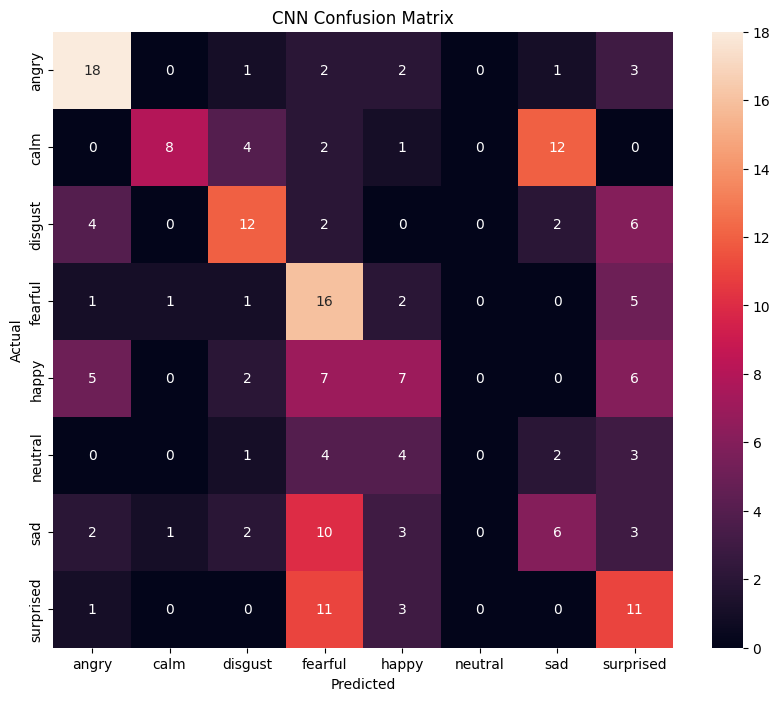

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN Confusion Matrix")

plt.show()

In [ ]:
print("CNN Accuracy:", test_accuracy)

CNN Accuracy: 0.38999998569488525


In [ ]:
print(manifest.iloc[0]["file_path"])

/content/drive/MyDrive/SER/data/raw/RAVDESS/Actor_01/03-01-01-01-01-01-01.wav


In [ ]:
print(X.min())
print(X.max())


-80.0
0.0


In [ ]:
X = (X - X.min()) / (X.max() - X.min())

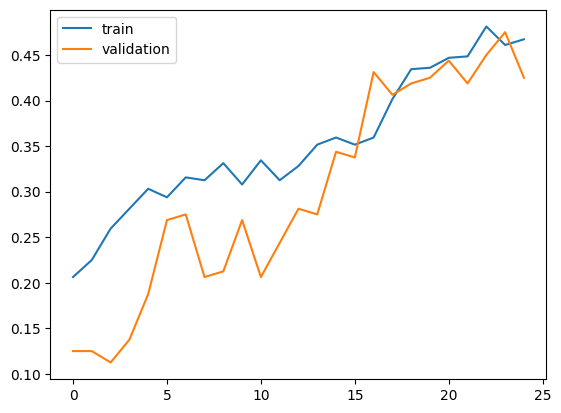

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['train','validation'])
plt.show()

In [ ]:
print("Best Validation Accuracy:",
      max(history.history["val_accuracy"]))

Best Validation Accuracy: 0.4749999940395355


In [ ]:
classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


'              precision    recall  f1-score   support\n\n       angry       0.58      0.67      0.62        27\n        calm       0.80      0.30      0.43        27\n     disgust       0.52      0.46      0.49        26\n     fearful       0.30      0.62      0.40        26\n       happy       0.32      0.26      0.29        27\n     neutral       0.00      0.00      0.00        14\n         sad       0.26      0.22      0.24        27\n   surprised       0.30      0.42      0.35        26\n\n    accuracy                           0.39       200\n   macro avg       0.38      0.37      0.35       200\nweighted avg       0.41      0.39      0.37       200\n'

In [ ]:
results = {
    "RandomForest_Accuracy": 0.445,
    "CNN_Accuracy": 0.39,
    "CNN_Best_Val_Accuracy": 0.475
}

print(results)

{'RandomForest_Accuracy': 0.445, 'CNN_Accuracy': 0.39, 'CNN_Best_Val_Accuracy': 0.475}
